In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

In [7]:
df = pd.read_csv("data/Final Asansol.csv", index_col="Timestamp")

# Sequential Modeling

### Preprocessing

In [8]:
df_train = df.loc[:'2023-12-31', ]
df_val = df.loc['2024-01-01':'2024-12-31', ]
df_test = df.loc['2025-01-01':, ]

Split dataset into train-validation-test 

Train Set: 2018 to 2023  
Validation Set: 2024  
Test Set: 1st January 2025 - 6th July 2025

In [9]:
scaler = MinMaxScaler()

train_sc = scaler.fit_transform(df_train)
val_sc = scaler.transform(df_val)
test_sc = scaler.transform(df_test)

train_scaled = pd.DataFrame(train_sc, columns=scaler.get_feature_names_out(), index = df_train.index)
val_scaled = pd.DataFrame(val_sc, columns=scaler.get_feature_names_out(), index = df_val.index)
test_scaled = pd.DataFrame(test_sc, columns=scaler.get_feature_names_out(), index=df_test.index)

LSTM requires features in same scale

In [10]:
def create_sequences(data, input_len=24, output_len=1):
    X, y = [], []
    
    for i in range(len(data) - input_len - output_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len, :4])
    
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)


X_train, y_train = create_sequences(train_scaled.values, input_len=24, output_len=1)
X_val, y_val = create_sequences(val_scaled.values, input_len=24, output_len=1)
X_test, y_test = create_sequences(test_scaled.values, input_len=24, output_len=1)

In [11]:
class AirQualityDataset(Dataset):
    
    def __init__(self, X, y):
        self.X = X
        self.y = y.squeeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = AirQualityDataset(X_train, y_train)
val_dataset = AirQualityDataset(X_val, y_val)
test_dataset = AirQualityDataset(X_test, y_test)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### LSTM

In [13]:
class LSTMModel(nn.Module):

    def __init__(self, input_size, output_size, hidden_size, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, num_layers=num_layers, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [14]:
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
            
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)

In [15]:
def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            
            loss = loss_fn(output, y_batch)
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel(input_size=10, output_size=4, hidden_size=64, num_layers=2).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

num_epochs = 30

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss = evaluate(model, val_loader, loss_fn, device)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.0028 | Val Loss: 0.0024
Epoch 2/30 | Train Loss: 0.0021 | Val Loss: 0.0016
Epoch 3/30 | Train Loss: 0.0014 | Val Loss: 0.0011
Epoch 4/30 | Train Loss: 0.0011 | Val Loss: 0.0009
Epoch 5/30 | Train Loss: 0.0008 | Val Loss: 0.0007
Epoch 6/30 | Train Loss: 0.0007 | Val Loss: 0.0005
Epoch 7/30 | Train Loss: 0.0006 | Val Loss: 0.0005
Epoch 8/30 | Train Loss: 0.0006 | Val Loss: 0.0005
Epoch 9/30 | Train Loss: 0.0006 | Val Loss: 0.0004
Epoch 10/30 | Train Loss: 0.0006 | Val Loss: 0.0004
Epoch 11/30 | Train Loss: 0.0006 | Val Loss: 0.0004
Epoch 12/30 | Train Loss: 0.0005 | Val Loss: 0.0004
Epoch 13/30 | Train Loss: 0.0005 | Val Loss: 0.0004
Epoch 14/30 | Train Loss: 0.0005 | Val Loss: 0.0004
Epoch 15/30 | Train Loss: 0.0005 | Val Loss: 0.0004
Epoch 16/30 | Train Loss: 0.0005 | Val Loss: 0.0004
Epoch 17/30 | Train Loss: 0.0005 | Val Loss: 0.0004
Epoch 18/30 | Train Loss: 0.0005 | Val Loss: 0.0004
Epoch 19/30 | Train Loss: 0.0005 | Val Loss: 0.0004
Epoch 20/30 | Train L

In [18]:
X_val_tensor = X_val.to(device)
y_pred = model(X_val_tensor).cpu().detach().numpy()  # [N, 4]
y_true = y_val.cpu().numpy()  # [N, 1, 4] or [N, 4]

if y_true.ndim == 3:
    y_true = y_true.squeeze(1)  # [N, 4]

# Get meteorological features from validation set (last 6 columns)
met_features = val_scaled.values[24:24+len(y_pred), 4:]  # [N, 6]

# Concatenate to get full 10 features
y_pred_full = np.concatenate([y_pred, met_features], axis=1)  # [N, 10]
y_true_full = np.concatenate([y_true, met_features], axis=1)  # [N, 10]

# Inverse transform
y_pred_inv = scaler.inverse_transform(y_pred_full)[:, :4]  # [N, 4]
y_true_inv = scaler.inverse_transform(y_true_full)[:, :4]  # [N, 4]

# Calculate metrics
mae = mean_absolute_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 6.72
RMSE: 12.17


In [19]:
print("y_pred shape:", y_pred.shape)
print("y_true shape:", y_true.shape)

df_val.shape

y_pred shape: (8735, 4)
y_true shape: (8735, 4)


(8760, 10)

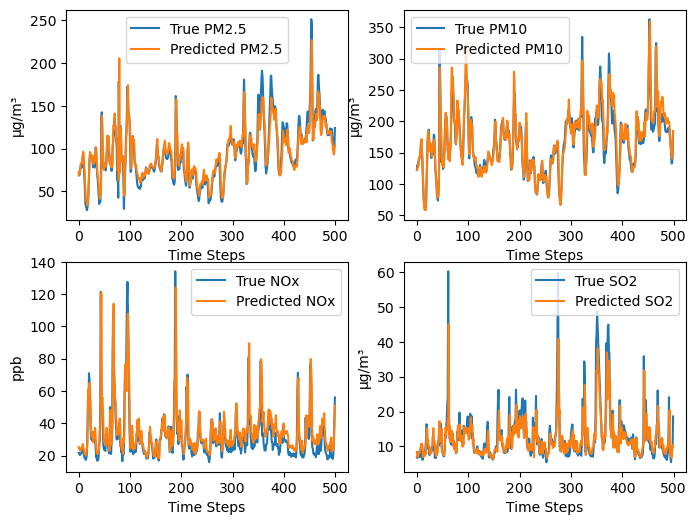

In [20]:
fig, ax = plt.subplots(2,2, figsize=(8, 6))
ax = ax.flatten()
labels = ["PM2.5", "PM10", "NOx", "SO2"]

for i in range(0,4):
    
    ax[i].plot(y_true_inv[:500, i], label=("True "+labels[i]))
    ax[i].plot(y_pred_inv[:500, i], label=("Predicted "+labels[i]))
    
    ax[i].set_xlabel("Time Steps")
    
    if(i!=2):
        ax[i].set_ylabel("µg/m³")
    else:
        ax[i].set_ylabel("ppb")
    
    ax[i].legend()
    
plt.show()

In [21]:
mae1 = mean_absolute_error(y_true_inv[:, 0], y_pred_inv[:, 0])
print("MAE on PM2.5 (µg/m³):", mae1)

mae2 = mean_absolute_error(y_true_inv[:, 1], y_pred_inv[:, 1])
print("MAE on PM10 (µg/m³):", mae2)

mae3 = mean_absolute_error(y_true_inv[:, 2], y_pred_inv[:, 2])
print("MAE on NOx ppb:", mae3)

mae4 = mean_absolute_error(y_true_inv[:, 3], y_pred_inv[:, 3])
print("MAE on SO2 (µg/m³):", mae4)

MAE on PM2.5 (µg/m³): 7.490293775721177
MAE on PM10 (µg/m³): 11.771325927164076
MAE on NOx ppb: 5.05893634611435
MAE on SO2 (µg/m³): 2.546321206545509


In [22]:
mse1 = mean_squared_error(y_true_inv[:, 0], y_pred_inv[:, 0])
print("MSE on PM2.5 (µg/m³):", mse1)

mse2 = mean_squared_error(y_true_inv[:, 1], y_pred_inv[:, 1])
print("MSE on PM10 (µg/m³):", mse2)

mse3 = mean_squared_error(y_true_inv[:, 2], y_pred_inv[:, 2])
print("MSE on NOx ppb:", mse3)

mse4 = mean_squared_error(y_true_inv[:, 3], y_pred_inv[:, 3])
print("MSE on SO2 (µg/m³):", mse4)

MSE on PM2.5 (µg/m³): 130.70128910722377
MSE on PM10 (µg/m³): 323.06297017920616
MSE on NOx ppb: 125.71946585630957
MSE on SO2 (µg/m³): 12.929108149873892


In [23]:
rmse1 = root_mean_squared_error(y_true_inv[:, 0], y_pred_inv[:, 0])
print("RMSE on PM2.5 (µg/m³):", rmse1)

rmse2 = root_mean_squared_error(y_true_inv[:, 1], y_pred_inv[:, 1])
print("RMSE on PM10 (µg/m³):", rmse2)

rmse3 = root_mean_squared_error(y_true_inv[:, 2], y_pred_inv[:, 2])
print("RMSE on NOx ppb:", rmse3)

rmse4 = root_mean_squared_error(y_true_inv[:, 3], y_pred_inv[:, 3])
print("RMSE on SO2 (µg/m³):", rmse4)

RMSE on PM2.5 (µg/m³): 11.432466448987453
RMSE on PM10 (µg/m³): 17.97395254748399
RMSE on NOx ppb: 11.212469213171092
RMSE on SO2 (µg/m³): 3.595706905446256
